# ETC Impacts on the Great Lakes: Figure Generation

This notebook regenerates the paper figures from precomputed outputs stored in the `processed/` directory. It does not repeat the main analysis or bootstrap calculations. Instead, it loads the saved summary tables and event-level storm data, recreates the final figures, and writes them to the `figures/` directory.

In [12]:
# ------------------------------
# 1. Imports and setup
# ------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42  # TrueType fonts
mpl.rcParams["ps.fonttype"] = 42

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = REPO_ROOT / "processed"
FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Figure dir:", FIG_DIR)

Repo root: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes
Processed dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed
Figure dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures


In [13]:
# ------------------------------
# 2. Save helper
# ------------------------------
def save_fig(fig, filename_base: str, dpi: int = 300) -> None:
    """
    Save figure as both PNG and PDF.

    filename_base should NOT include extension.
    """
    png_path = FIG_DIR / f"{filename_base}.png"
    pdf_path = FIG_DIR / f"{filename_base}.pdf"

    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.close(fig)

## Load precomputed analysis outputs

These tables were generated in the impact-analysis notebook and are loaded here directly so that the figures can be reproduced without repeating the full analysis.

In [14]:
# ------------------------------
# 3. Load processed outputs
# ------------------------------
rr_df_all = pd.read_csv(PROCESSED_DIR / "rr_df_all_seasons.csv")
rr_df_seasons = pd.read_csv(PROCESSED_DIR / "rr_df_by_season.csv")

season_counts = pd.read_csv(
    PROCESSED_DIR / "storm_counts_by_season_and_type.csv",
    index_col=0,
)
season_frac = pd.read_csv(
    PROCESSED_DIR / "storm_fraction_by_season_and_type.csv",
    index_col=0,
)
month_counts = pd.read_csv(
    PROCESSED_DIR / "storm_counts_by_month_and_type.csv",
    index_col=0,
)
month_frac = pd.read_csv(
    PROCESSED_DIR / "storm_fraction_by_month_and_type.csv",
    index_col=0,
)

df = pd.read_csv(PROCESSED_DIR / "cfsr_storms_labeled_k2.csv")

TYPE1 = "Type 1 (Earlier-entry storms)"
TYPE2 = "Type 2 (Later-entry storms)"

assert "storm_type" in df.columns, "storm_type not found. Re-run 02_build_gmm_model.ipynb."

In [15]:
# ------------------------------
# 4. Plot metadata
# ------------------------------
LAKE_ORDER = ["sup", "mi", "huron", "erie", "ont"]
LAKE_LABELS = {
    "sup": "Superior",
    "mi": "Michigan",
    "huron": "Huron",
    "erie": "Erie",
    "ont": "Ontario",
}

SEASON_TITLES = {
    "DJF": "Winter (DJF)",
    "MAM": "Spring (MAM)",
    "JJA": "Summer (JJA)",
    "SON": "Fall (SON)",
}

## Forest-plot helpers

In [16]:
# ------------------------------
# 5. Forest-plot helpers
# ------------------------------
def prep_for_plot(
    rr_df: pd.DataFrame,
    impact: str,
    season: str | None = None,
) -> pd.DataFrame:
    out = rr_df[rr_df["impact"] == impact].copy()
    if season is not None:
        out = out[out["season"] == season].copy()

    out["lake"] = out["lake"].astype(str).str.lower()
    out = out[out["lake"].isin(LAKE_ORDER)]
    out["lake_label"] = out["lake"].map(LAKE_LABELS)
    out["lake"] = pd.Categorical(out["lake"], categories=LAKE_ORDER, ordered=True)

    return out.sort_values("lake").reset_index(drop=True)


def forest(
    ax,
    df_plot: pd.DataFrame,
    metric: str,
    title: str,
    xlabel: str,
    ref_value: float | None = None,
):
    if df_plot.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.text(
            0.5,
            0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            alpha=0.7,
        )
        ax.set_yticks([])
        if ref_value is not None:
            ax.axvline(ref_value, linestyle="--", linewidth=1)
        ax.grid(True, axis="x", alpha=0.3)
        return

    y = np.arange(len(df_plot))
    median = df_plot[f"{metric}_median"].to_numpy()
    low = df_plot[f"{metric}_low"].to_numpy()
    high = df_plot[f"{metric}_high"].to_numpy()
    xerr = np.vstack([median - low, high - median])

    ax.errorbar(median, y, xerr=xerr, fmt="o", capsize=3)

    if ref_value is not None:
        ax.axvline(ref_value, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["lake_label"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)

## Forest plots

In [17]:
# ------------------------------
# 6. Forest plots
# ------------------------------
def add_panel_labels(axes, labels):
    for ax, label in zip(axes.flatten(), labels):
        ax.text(
            -0.08,
            1.10,
            label,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

In [18]:
def plot_all_seasons_2x2(rr_df_all: pd.DataFrame):
    d_evap = prep_for_plot(rr_df_all, "evap")
    d_precip = prep_for_plot(rr_df_all, "precip")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(
        axes[0, 0],
        d_evap,
        "rr",
        "Evaporation extremes: Risk ratio",
        "P(Extreme | Later Entry) / P(Extreme | Earlier Entry)",
        1.0,
    )
    forest(
        axes[0, 1],
        d_evap,
        "rd",
        "Evaporation extremes: Risk difference",
        "P(Extreme | Later Entry) - P(Extreme | Earlier Entry)",
        0.0,
    )
    forest(
        axes[1, 0],
        d_precip,
        "rr",
        "Precipitation extremes: Risk ratio",
        "P(Extreme | Later Entry) / P(Extreme | Earlier Entry)",
        1.0,
    )
    forest(
        axes[1, 1],
        d_precip,
        "rd",
        "Precipitation extremes: Risk difference",
        "P(Extreme | Later Entry) - P(Extreme | Earlier Entry)",
        0.0,
    )

    add_panel_labels(axes, ["(a)", "(b)", "(c)", "(d)"])

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    return fig, axes

In [19]:
def plot_takehome_son_evap_jja_precip(rr_df_seasons: pd.DataFrame):
    d_evap_son = prep_for_plot(rr_df_seasons, "evap", season="SON")
    d_precip_jja = prep_for_plot(rr_df_seasons, "precip", season="JJA")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(
        axes[0, 0],
        d_evap_son,
        "rr",
        "Fall (SON) evaporation extremes: Risk ratio",
        "P(Extreme | Later Entry) / P(Extreme | Earlier Entry)",
        1.0,
    )
    forest(
        axes[0, 1],
        d_evap_son,
        "rd",
        "Fall (SON) evaporation extremes: Risk difference",
        "P(Extreme | Later Entry) - P(Extreme | Earlier Entry)",
        0.0,
    )
    forest(
        axes[1, 0],
        d_precip_jja,
        "rr",
        "Summer (JJA) precipitation extremes: Risk ratio",
        "P(Extreme | Later Entry) / P(Extreme | Earlier Entry)",
        1.0,
    )
    forest(
        axes[1, 1],
        d_precip_jja,
        "rd",
        "Summer (JJA) precipitation extremes: Risk difference",
        "P(Extreme | Later Entry) - P(Extreme | Earlier Entry)",
        0.0,
    )

    add_panel_labels(axes, ["(a)", "(b)", "(c)", "(d)"])

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    fig.tight_layout(rect=[0.03, 0.03, 1, 0.97])
    return fig, axes

## Diagnostics

In [20]:
# ------------------------------
# 7. Diagnostic plots
# ------------------------------
def plot_monthly_distribution(month_frac: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(9, 4))
    month_frac.plot(kind="bar", ax=ax)
    ax.set_ylabel("Fraction of storms")
    ax.set_xlabel("Month")
    ax.set_title("Monthly distribution of storm types")
    ax.legend(title="Storm type")
    fig.tight_layout()
    return fig, ax

## Feature distributions by storm type

In [21]:
# ------------------------------
# 8. Feature distributions
# ------------------------------
def plot_feature_distributions(df: pd.DataFrame):
    features = [
        "maturity_glr0_minus_genesis_ratio",
        "fraction_of_time_in_GLR",
        "max_radius",
        "min_p_cent",
        "max_uv",
        "max_p_grad",
    ]

    var_labels = {
        "maturity_glr0_minus_genesis_ratio": "Time-to-GLR / lifetime ratio",
        "fraction_of_time_in_GLR": "Fraction of storm lifetime in GLR",
        "max_radius": "Maximum storm radius (km)",
        "min_p_cent": "Minimum central pressure (hPa)",
        "max_uv": "Maximum propagation speed (km hr$^{-1}$)",
        "max_p_grad": "Maximum pressure gradient (hPa)",
    }

    storm_types = [TYPE1, TYPE2]
    colors = {
        TYPE1: "tab:blue",
        TYPE2: "tab:orange",
    }
    panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

    missing = [col for col in (features + ["storm_type"]) if col not in df.columns]
    if missing:
        raise ValueError(
            f"Event-level dataframe is missing columns needed for feature plot: {missing}"
        )

    fig, axes = plt.subplots(2, 3, figsize=(11, 6))
    axes = axes.flatten()

    for i, (ax, var) in enumerate(zip(axes, features)):
        data_all = df[var].dropna()
        if data_all.empty:
            ax.set_title(var_labels.get(var, var), fontsize=10)
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                alpha=0.7,
            )
            ax.set_yticks([])
            continue

        bins = np.histogram_bin_edges(data_all, bins=30)

        hist_counts = {}
        max_count = 0
        for storm_type in storm_types:
            vals = df.loc[df["storm_type"] == storm_type, var].dropna()
            counts, _ = np.histogram(vals, bins=bins)
            hist_counts[storm_type] = counts
            max_count = max(max_count, counts.max() if len(counts) else 0)

        max_count = max(max_count, 1)

        for storm_type in storm_types:
            y = hist_counts[storm_type] / max_count
            ax.step(
                bins[:-1],
                y,
                where="post",
                color=colors[storm_type],
                linewidth=1.5,
                label=storm_type if i == 0 else None,
            )
            ax.fill_between(
                bins[:-1],
                y,
                step="post",
                color=colors[storm_type],
                alpha=0.35,
            )

        ax.set_title(var_labels.get(var, var), fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Relative frequency")

        ax.text(
            -0.08,
            1.10,
            panel_labels[i],
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

        if i == 0:
            ax.set_xlim(0, 0.95)
            ax.legend(frameon=False, fontsize=9)
        elif i == 1:
            ax.set_xlim(0, 0.95)
        elif i == 2:
            ax.set_xlim(300, 3000)
        elif i == 3:
            ax.set_xlim(960, 1020)
        elif i == 4:
            ax.set_xlim(30, 180)
        elif i == 5:
            ax.set_xlim(8, 45)

    fig.tight_layout()
    return fig, axes

## Generate and save figures

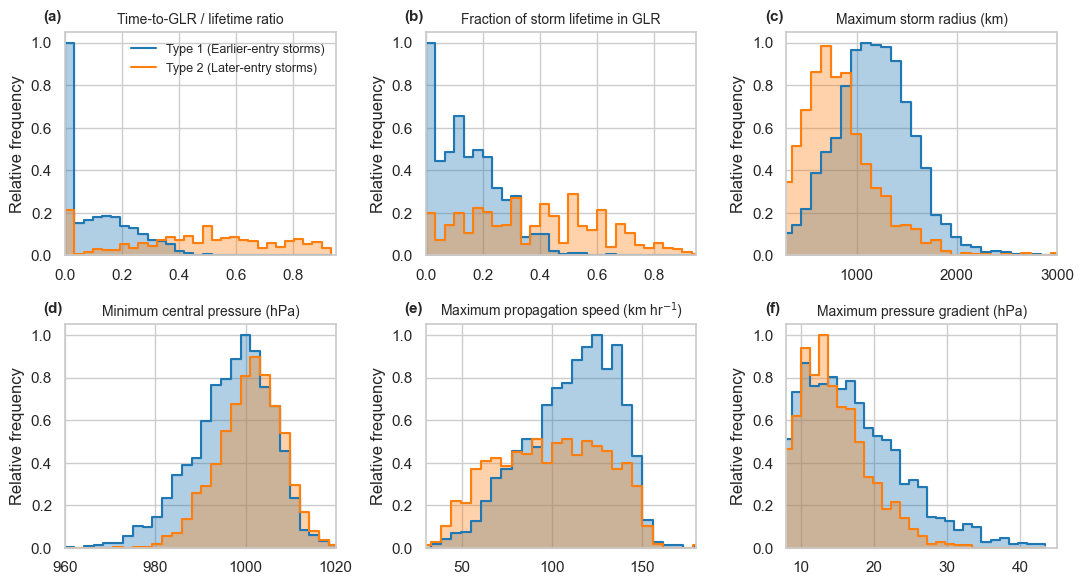

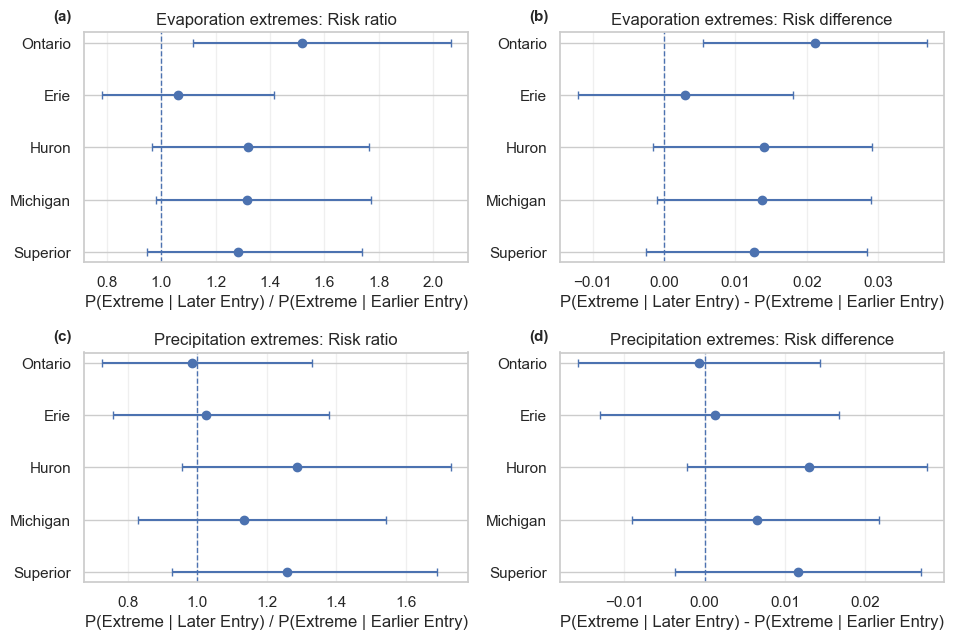

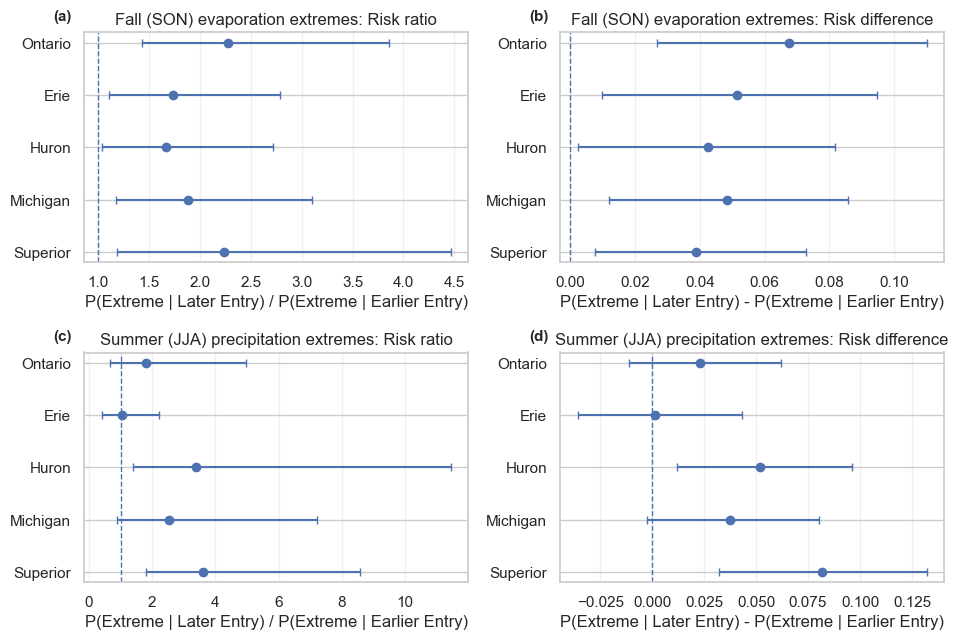

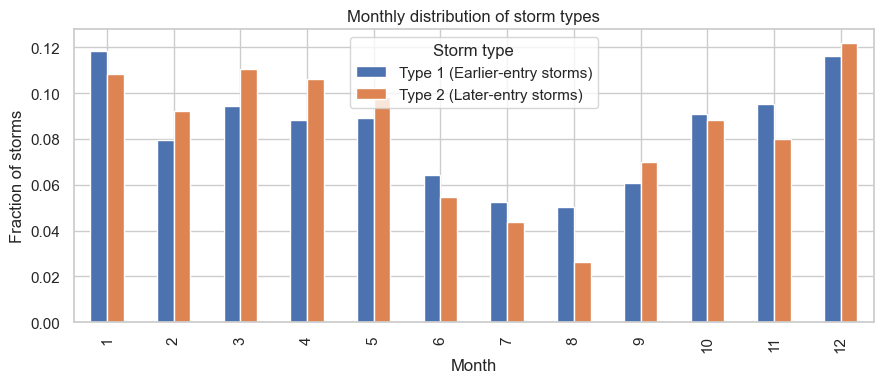

Saved figures to: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures


In [22]:
# ------------------------------
# 9. Generate and save figures
# ------------------------------
fig, _ = plot_feature_distributions(df)
plt.show()
save_fig(fig, "fig_feature_distributions_by_type")

fig, _ = plot_all_seasons_2x2(rr_df_all)
plt.show()
save_fig(fig, "fig_all_seasons_rr_rd_2x2")

fig, _ = plot_takehome_son_evap_jja_precip(rr_df_seasons)
plt.show()
save_fig(fig, "fig_takehome_son_evap_jja_precip_2x2")

fig, _ = plot_monthly_distribution(month_frac)
plt.show()
save_fig(fig, "fig_monthly_distribution_storm_types")

print(f"Saved figures to: {FIG_DIR}")

## Summary

This notebook regenerates the figure panels used in the paper from precomputed processed outputs and saves them to the `figures/` directory.